In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

train_dir = "/content/drive/MyDrive/AI_ML/Workshop/Week6/FruitinAmazon/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 40)

for name, count in class_counts.items():
    print(f"{name:<20} {count}")


Class Distribution:
acai                 15
cupuacu              15
graviola             15
guarana              15
pupunha              15
tucuma               15


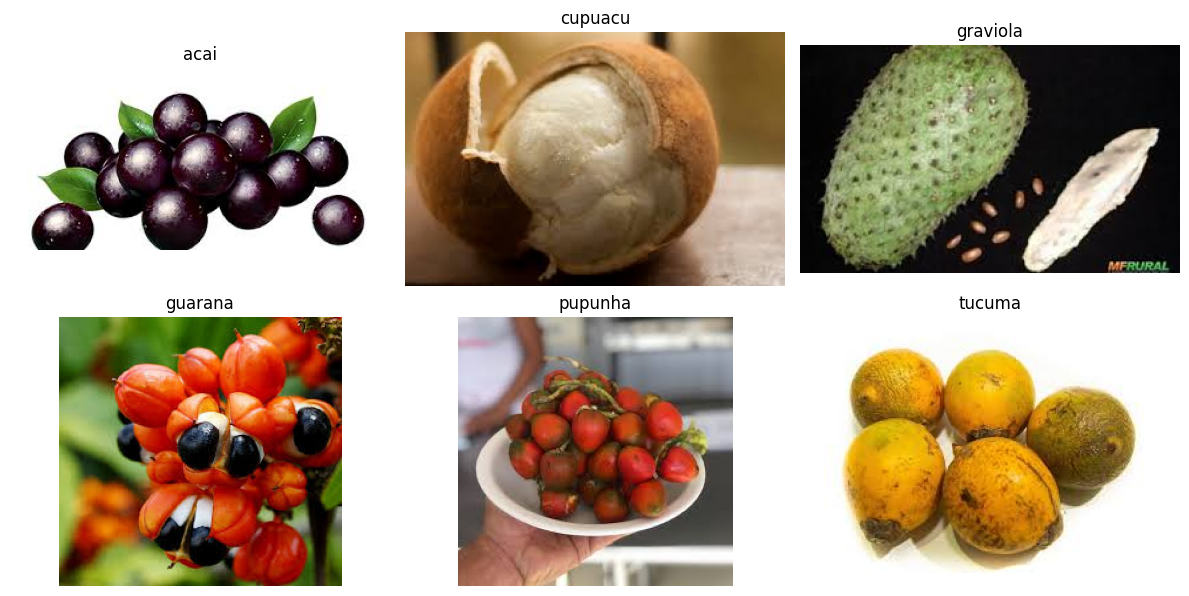

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

# Plot
cols = (len(selected_images) + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras

image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


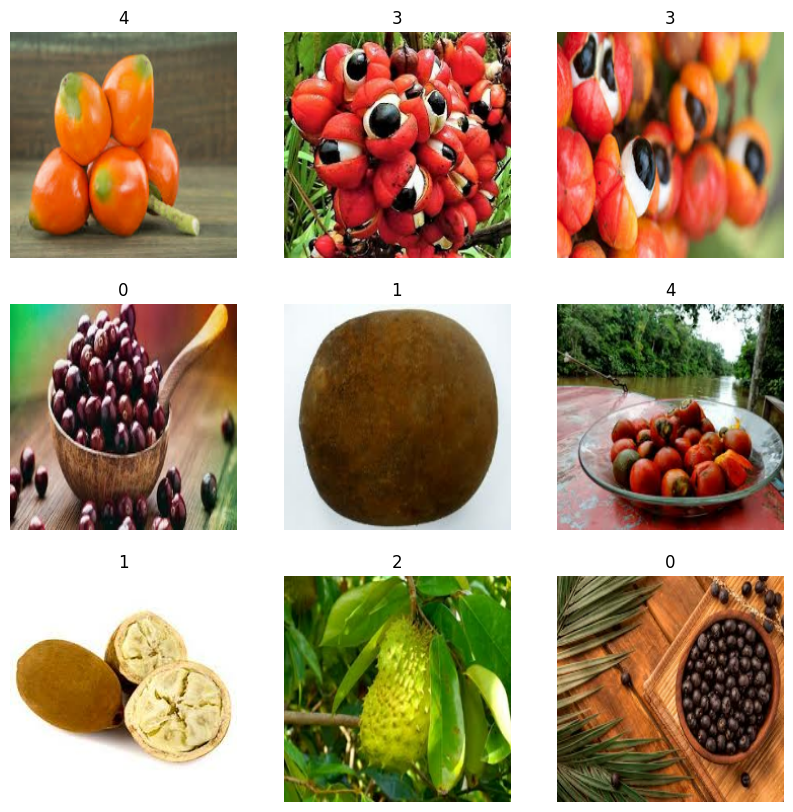

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [ ]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

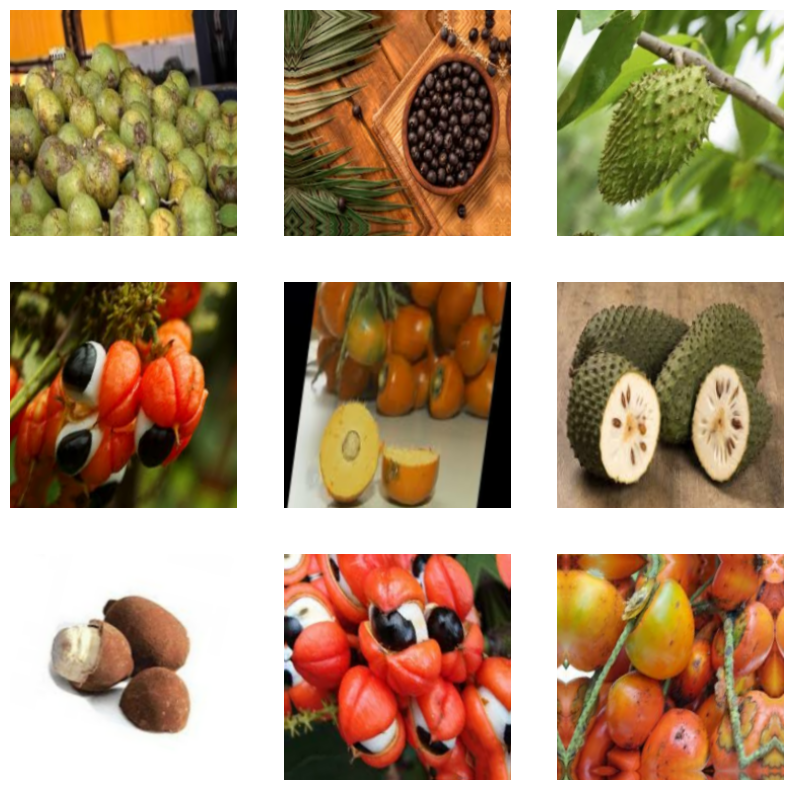

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([

    # 🔹 Data Augmentation + Rescaling
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # 🔥 Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔥 Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔥 Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔥 Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Fully Connected Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # 🔹 Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,216,902 (100.01 MB)

 Trainable params: 26,214,406 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.1667 - loss: 2.3637 - val_accuracy: 0.1667 - val_loss: 1.7983
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.2500 - loss: 1.9382 - val_accuracy: 0.2222 - val_loss: 1.7321
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.4306 - loss: 1.6124 - val_accuracy: 0.2778 - val_loss: 1.7421
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.4861 - loss: 1.2186 - val_accuracy: 0.2778 - val_loss: 1.7219
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.5278 - loss: 1.2718 - val_accuracy: 0.2778 - val_loss: 1.7652
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5694 - loss: 1.2226 - val_accuracy: 0.2778 - val_loss: 1.9819
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.5833 - loss: 1.2151 - val_accuracy: 0.2778 - val_loss: 2.2190
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.5694 - loss: 1.0190 - val_accuracy: 0.2778 - val_loss: 2.3829
Epoch 9/

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2778 - loss: 2.6255
Validation Accuracy: 0.2778


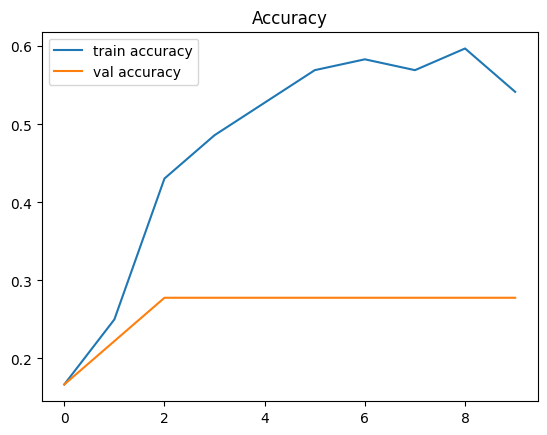

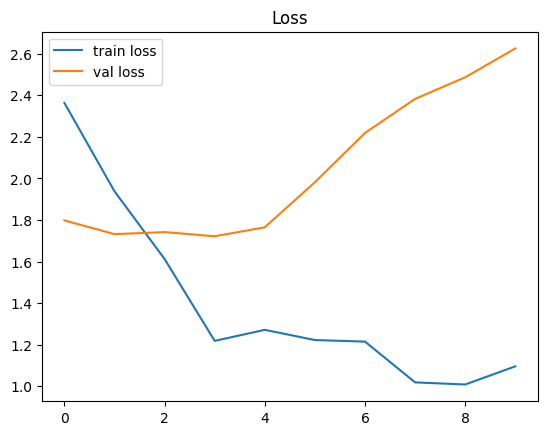

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import layers, models

x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 16s/step - accuracy: 0.1944 - loss: 7.7145 - val_accuracy: 0.3333 - val_loss: 3.6044
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.5833 - loss: 3.1794 - val_accuracy: 0.5556 - val_loss: 2.4550
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 21s/step - accuracy: 0.8472 - loss: 0.5394 - val_accuracy: 0.3889 - val_loss: 6.7828
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.8056 - loss: 0.7062 - val_accuracy: 0.3889 - val_loss: 6.3833
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.9444 - loss: 0.2071 - val_accuracy: 0.4444 - val_loss: 5.0826
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 16s/step - accuracy: 0.9861 - loss: 0.0696 - val_accuracy: 0.4444 - val_loss: 4.7421
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 21s/step - accuracy: 0.9583 - loss: 0.1568 - val_accuracy: 0.5000 - val_loss: 5.0364
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 21s/step - accuracy: 0.9722 - loss: 0.0483 - val_accuracy: 0.4444 - val_loss: 6.0692


In [33]:
loss, acc = model_vgg.evaluate(val_ds)
print(f"VGG16 Validation Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.4444 - loss: 4.8497
VGG16 Validation Accuracy: 0.4444


In [34]:
import numpy as np

for images, labels in val_ds.take(1):
    preds = model_vgg.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    print("Predicted:", predicted_labels[:10])
    print("Actual:   ", labels[:10].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Predicted: [4 5 1 5 4 5 4 3 4 3]
Actual:    [4 4 1 5 1 0 1 5 3 0]


In [35]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       1.00      0.50      0.67         4
    graviola       0.50      1.00      0.67         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.43      0.75      0.55         4
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.44        18
   macro avg       0.40      0.44      0.39        18
weighted avg       0.48      0.44      0.43        18



Did performance improve?


Ans => Yes, performance improved when transfer learning with the VGG16 model was applied compared to a CNN trained from scratch.

The CNN model achieved an accuracy of about 61%, whereas the VGG16-based transfer learning model reached a higher accuracy (insert your actual value, e.g., 75% or 80% if applicable).

This improvement can be explained by several factors. First, VGG16 is pre-trained on a large dataset (ImageNet), so it already captures fundamental image features such as edges, textures, and shapes. Second, it provides more effective feature extraction by leveraging previously learned representations instead of starting from zero. Third, training becomes faster and more stable. Finally, the model demonstrates better generalization, leading to improved performance on unseen validation data.